In [4]:
from pathlib import Path
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data_dir = Path("data/samitrop_wfdb")

hea_files = sorted(data_dir.glob("*.hea"))
print("Number of WFDB records:", len(hea_files))

first_record_path = hea_files[0].with_suffix("")
print("First record:", first_record_path)

Number of WFDB records: 1631
First record: data/samitrop_wfdb/100726


In [6]:
record = wfdb.rdrecord(str(first_record_path))

print("Sampling frequency:", record.fs)
print("Number of leads:", record.n_sig)
print("Signal length:", record.sig_len)
print("Lead names:", record.sig_name)
print("Comments:", record.comments)

Sampling frequency: 400
Number of leads: 12
Signal length: 2934
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Comments: ['Age: 64', 'Sex: Male', 'Chagas label: True', 'Source: SaMi-Trop']


In [7]:
def get_comment_value(record, key):
    for comment in record.comments:
        if comment.lower().startswith(key.lower() + ":"):
            return comment.split(":", 1)[1].strip()
    return None

age = get_comment_value(record, "Age")
sex = get_comment_value(record, "Sex")

print("Age:", age)
print("Sex:", sex)

Age: 64
Sex: Male


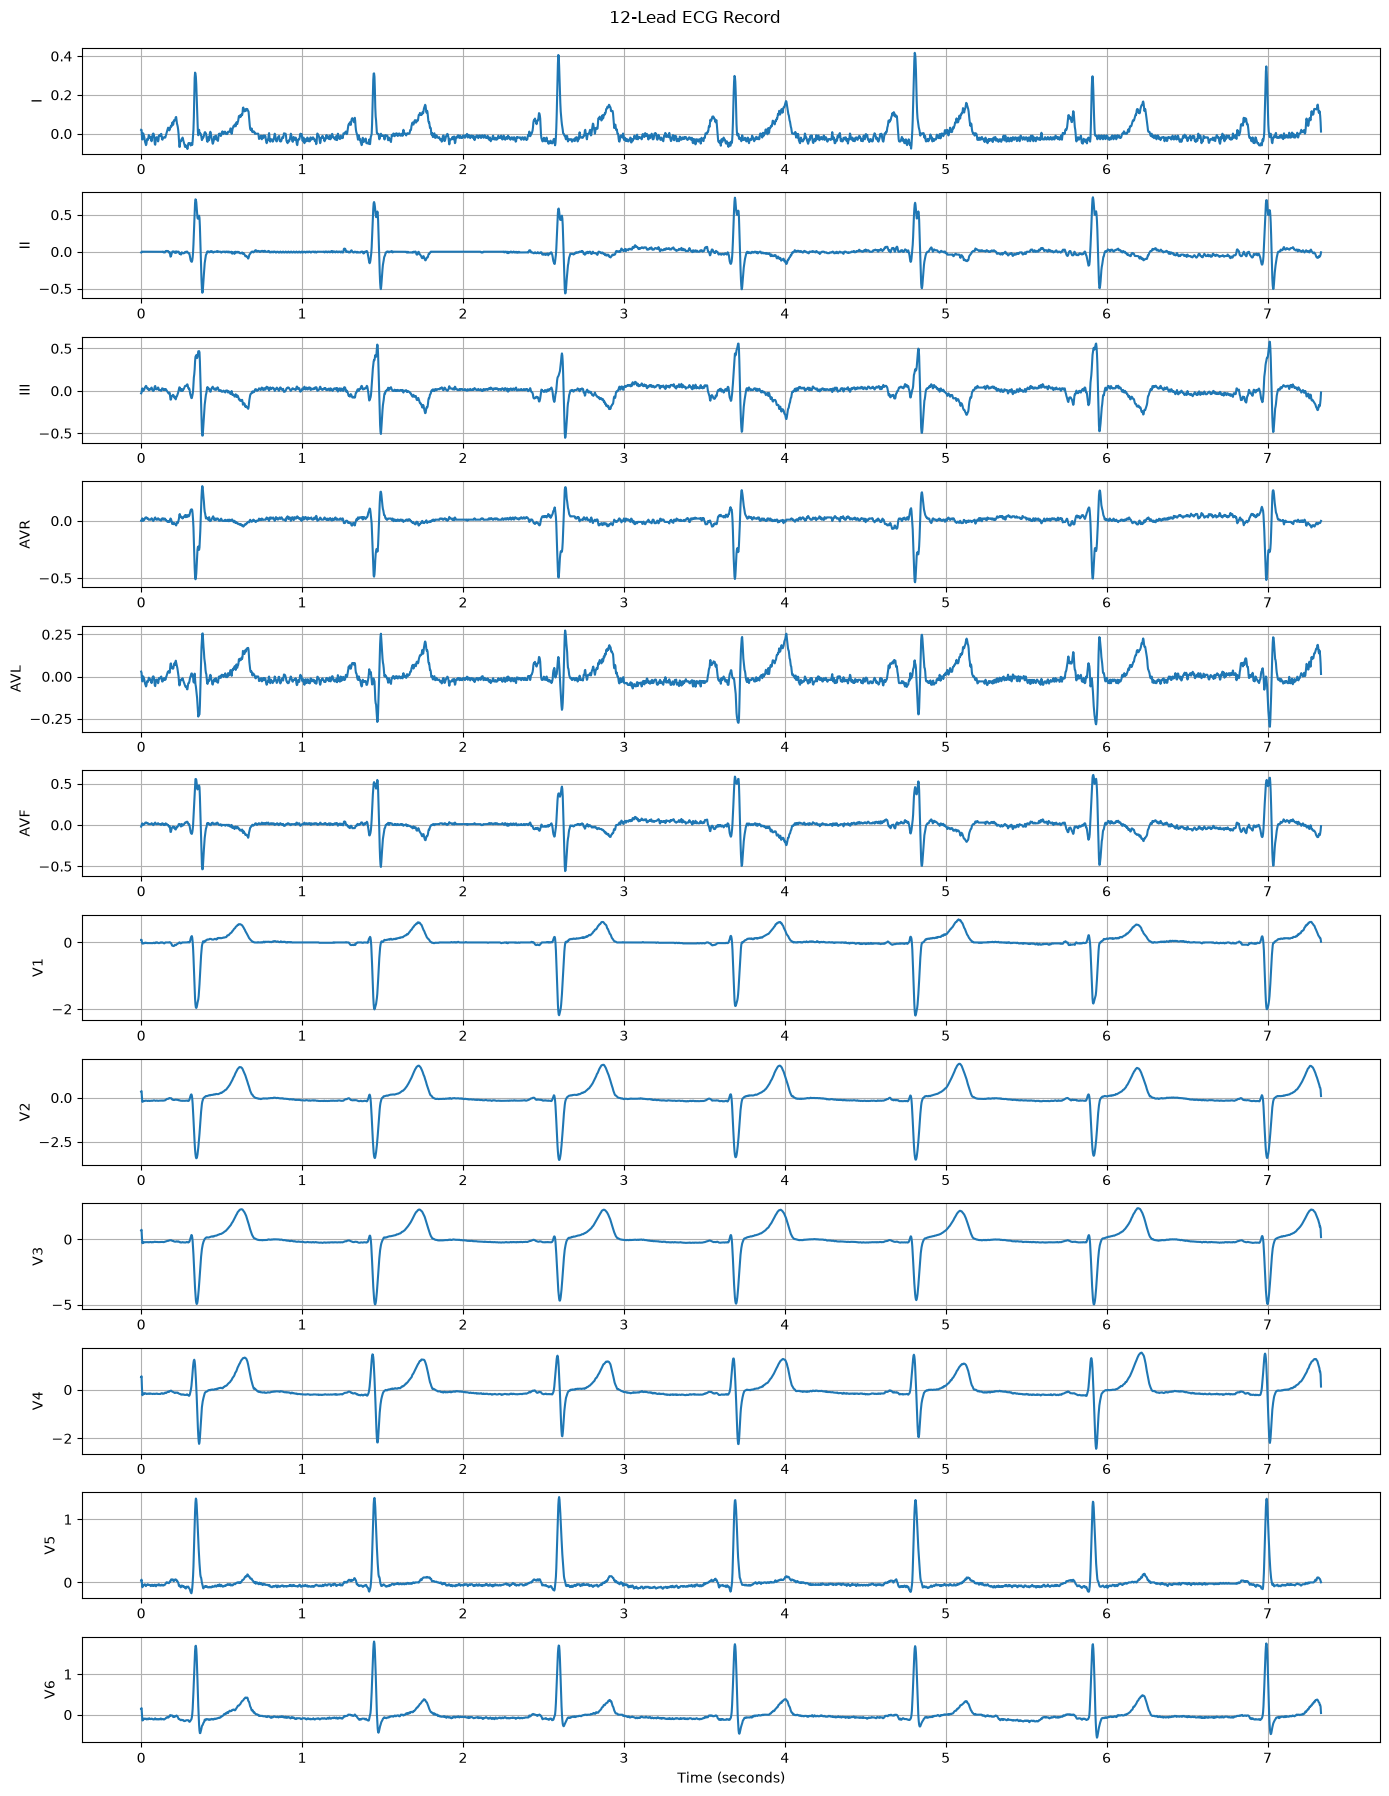

In [8]:
signal = record.p_signal
time = [i / record.fs for i in range(record.sig_len)]

plt.figure(figsize=(14, 18))

for i, lead in enumerate(record.sig_name):
    plt.subplot(12, 1, i + 1)
    plt.plot(time, signal[:, i])
    plt.ylabel(lead)
    plt.grid(True)

plt.xlabel("Time (seconds)")
plt.suptitle("12-Lead ECG Record", y=0.995)
plt.tight_layout()
plt.show()

In [9]:
metadata_list = []

for hea_file in hea_files[:20]:
    rec_path = hea_file.with_suffix("")
    rec = wfdb.rdrecord(str(rec_path))
    
    metadata_list.append({
        "record_name": rec.record_name,
        "sampling_frequency": rec.fs,
        "num_leads": rec.n_sig,
        "signal_length": rec.sig_len,
        "age": get_comment_value(rec, "Age"),
        "sex": get_comment_value(rec, "Sex"),
        "lead_names": rec.sig_name,
    })

metadata_df = pd.DataFrame(metadata_list)
metadata_df

,record_name,sampling_frequency,num_leads,signal_length,age,sex,lead_names
0,100726,400,12,2934,64,Male,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
1,101191,400,12,2934,49,Male,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
2,101193,400,12,2934,68,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
3,101282,400,12,2934,70,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
4,101842,400,12,2934,49,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
5,102640,400,12,2934,72,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
6,103042,400,12,2934,48,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
7,103725,400,12,2934,74,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
8,104023,400,12,2934,85,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."
9,105406,400,12,2934,76,Female,"[I, II, III, AVR, AVL, AVF, V1, V2, V3, V4, V5..."


In [10]:
metadata_df.to_csv("week2_metadata_20_records.csv", index=False)
print("Saved week2_metadata_20_records.csv")

Saved week2_metadata_20_records.csv
